In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv(r"C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\data\Give_risks\GiveMeSomeCredit-testing.csv").drop(columns=['Unnamed: 0'])

In [46]:
df.head(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [47]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [48]:
df.dtypes

SeriousDlqin2yrs                        float64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [49]:
for col in df.columns:
    print(f"{col}, {df[col].unique()}")

SeriousDlqin2yrs, [nan]
RevolvingUtilizationOfUnsecuredLines, [0.88551908 0.46329527 0.04327504 ... 0.08159637 0.33545655 0.44184166]
age, [ 43  57  59  38  27  63  50  79  68  23  37  52  30  56  28  72  29  48
  61  69  51  45  67  34  47  44  55  54  49  32  41  40  46  60  80  87
  36  74  53  31  71  62  25  22  26  33  42  58  39  64  93  65  76  78
  35  66  77  73  84  24  75  82  89  70  95  21  86  91  83  81  96  88
  92  85  90  94 101  99  98  97 104 100]
NumberOfTime30-59DaysPastDueNotWorse, [ 0  1 98  2  4  3  8  5  6  7  9 10 96 12 11 19]
DebtRatio, [1.77512717e-01 5.27236928e-01 6.87647522e-01 ... 9.34217437e-01
 3.56800000e+03 1.98918371e-01]
MonthlyIncome, [ 5700.  9141.  5083. ...  5719. 43333. 67749.]
NumberOfOpenCreditLinesAndLoans, [ 4 15 12  7  5  8  0  6 16 14 10 13 17  1 20  9 25 21 23  2 18 22  3 11
 32 31 19 24 29 41 27 37 45 28 26 35 36 38 33 34 30 40 53 44 47 43 39 51
 63 58 52 85 49 42 48 46]
NumberOfTimes90DaysLate, [ 0 98  1  2  3  5  4  8  6  9  7 96 1

In [50]:
ER = df["SeriousDlqin2yrs"].sum() / len(df)

In [51]:
ER

0.0

Event Rate - доля положительных событий в выборке составляет всего 6,7% , что говорит о некотором дисбалансе и это надо учесть при обработке и подгатовке даных

Теперь, согласно плану проверим пропущенные значения по всем колонкам и ключевым

In [52]:
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'percent_missing': percent_missing})
print(missing_value_df.round(3))

                                      percent_missing
SeriousDlqin2yrs                              100.000
RevolvingUtilizationOfUnsecuredLines            0.000
age                                             0.000
NumberOfTime30-59DaysPastDueNotWorse            0.000
DebtRatio                                       0.000
MonthlyIncome                                  19.805
NumberOfOpenCreditLinesAndLoans                 0.000
NumberOfTimes90DaysLate                         0.000
NumberRealEstateLoansOrLines                    0.000
NumberOfTime60-89DaysPastDueNotWorse            0.000
NumberOfDependents                              2.587


Итак, всего у нас 19,821 % пропусков в MontlyIncome и 2,616 в NumberofDependents - в ежемемячном доходе
получается 20 процентов пропусков и в кол-ве иждевенцев почти 3 процента, надо будет обрабатывать ежемесячный доход

MCAR / MAR / MNAR для MonthlyIncome

In [53]:
missing_mask = df["MonthlyIncome"].isnull()
print(df.loc[missing_mask,  "SeriousDlqin2yrs"].mean())  # дефолт среди пропусков
print(df.loc[~missing_mask, "SeriousDlqin2yrs"].mean())  # дефолт среди заполненных

nan
nan


MCAR / MAR / MNAR для NumberOfDependents

In [54]:
missing_mask = df["NumberOfDependents"].isnull()
print(df.loc[missing_mask,  "SeriousDlqin2yrs"].mean())  # дефолт среди пропусков
print(df.loc[~missing_mask, "SeriousDlqin2yrs"].mean())  # дефолт среди заполненных

nan
nan


In [55]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

# NumberOfDependents — MAR, флаг желателен
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isnull().astype(int)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)


In [56]:
# col = "NumberOfTimes90DaysLate", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"
col = "NumberOfTimes90DaysLate"
print(df[col].value_counts().sort_index())

# Сравниваем дефолт у 96/98 vs нормальных
mask_96 = df[col] == 96
mask_98 = df[col] == 98

print(f"Дефолт при значении 96: {df.loc[mask_96, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт при значении 98: {df.loc[mask_98, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт в целом:         {df['SeriousDlqin2yrs'].mean():.4f}")


NumberOfTimes90DaysLate
0     95785
1      3594
2      1062
3       445
4       191
5       102
6        44
7        26
8        19
9        14
10        2
11        1
12        1
16        1
17        1
18        1
96        1
98      213
Name: count, dtype: int64
Дефолт при значении 96: nan
Дефолт при значении 98: nan
Дефолт в целом:         nan


Их матрицы корреляции фичей + значения при просрочах аномальные (96 и 98) принято решение заменить их на наны и 0 + добавить флаги (метки), дабы учитывать их риск при классификации клиента

In [57]:
#ставим метку если один из них такой
df["HasHiddenLatePayments"] = (
    (df["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98])) |
    (df["NumberOfTimes90DaysLate"].isin([96, 98]))              |
    (df["NumberOfTime60-89DaysPastDueNotWorse"].isin([96, 98]))
).astype(int)

late_cols = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"]

for col in late_cols:
    df[col] = df[col].replace({96: np.nan, 98: np.nan})
    df[col] = df[col].fillna(df[col].median())

df["TotalLatePayments_weighted"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df["NumberOfTimes90DaysLate"]              * 3
)

# Удаляем оригинальные
#train.drop(columns=late_cols, inplace=True)

print(df.shape)

(101503, 15)


Теперь посмотрим на выбросы, сначала с поомщью бокс-плот 

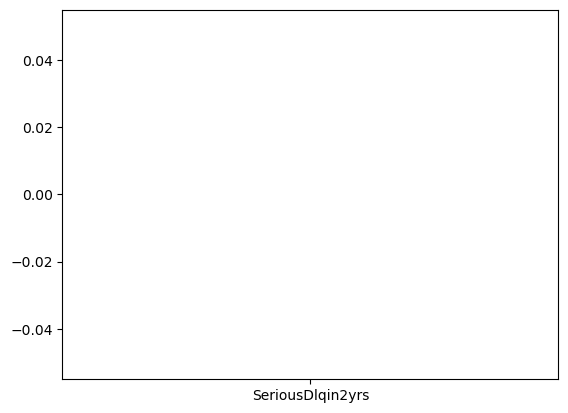

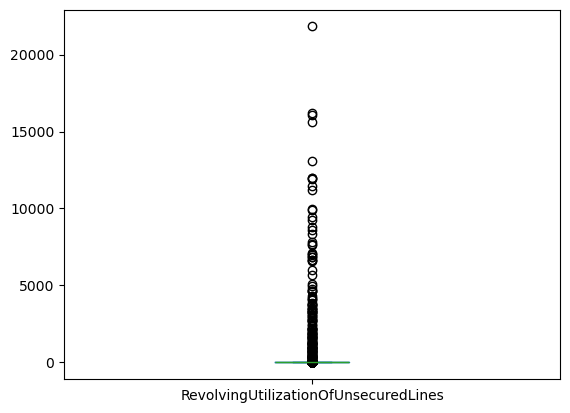

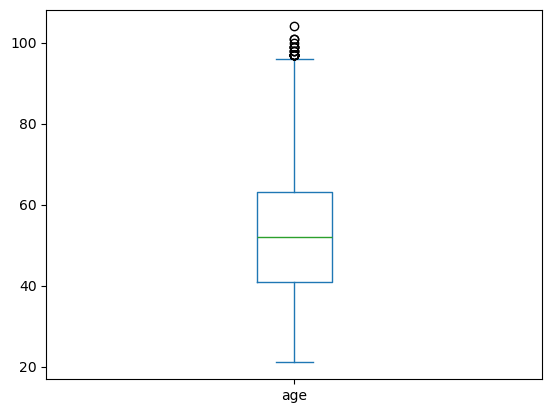

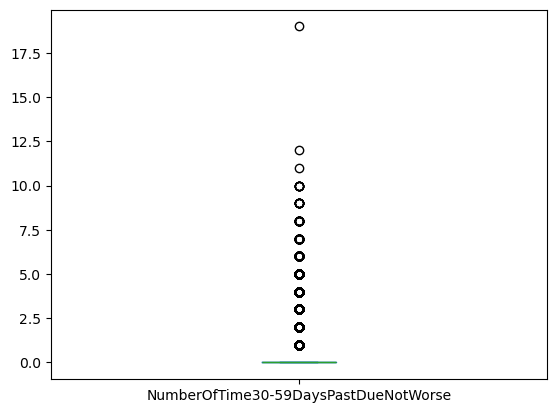

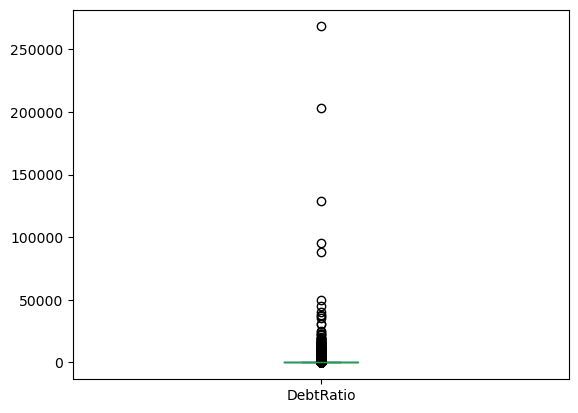

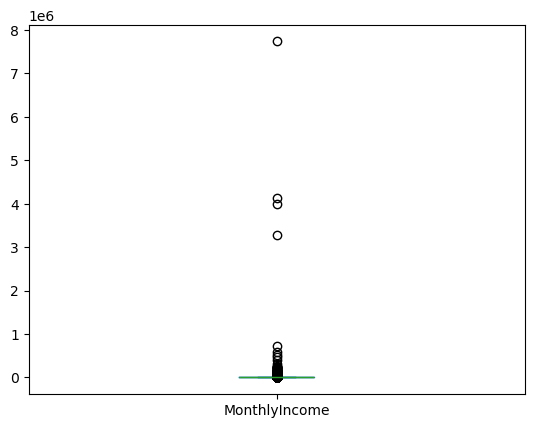

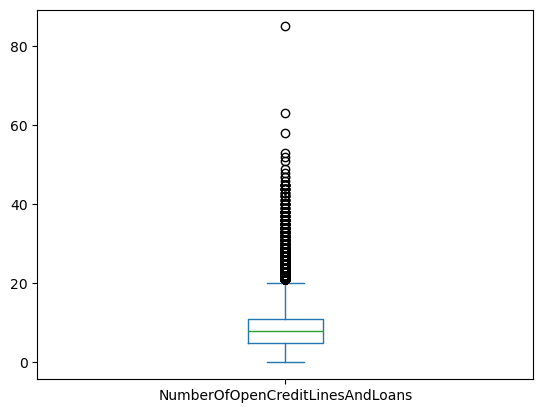

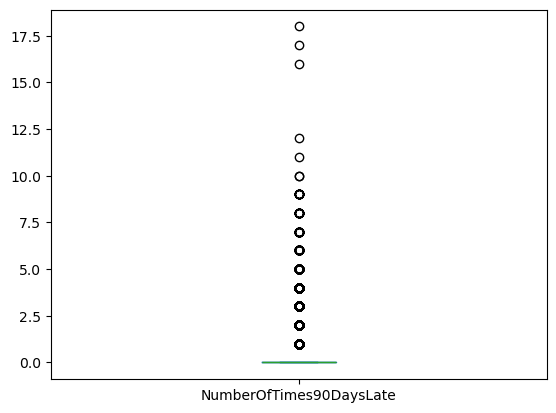

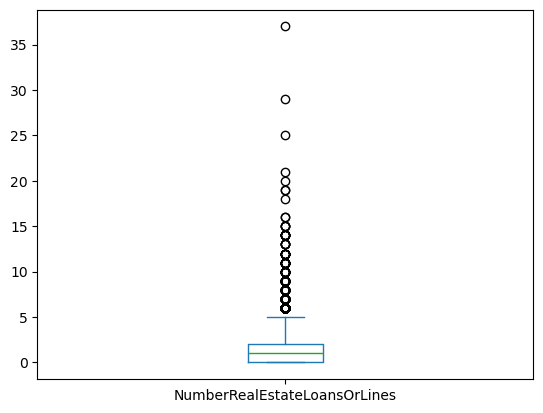

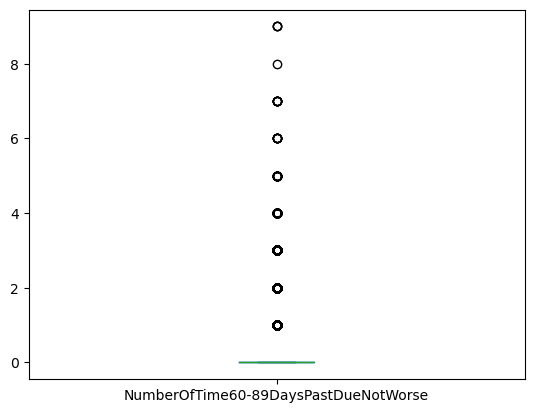

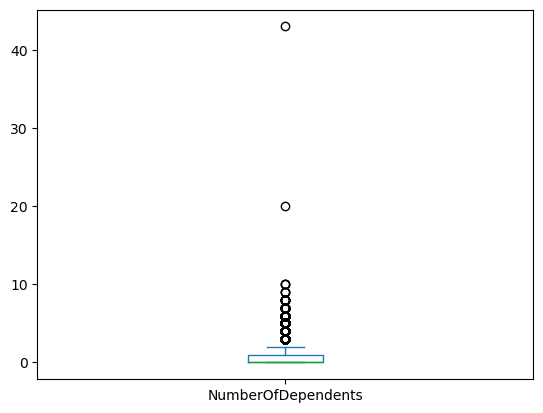

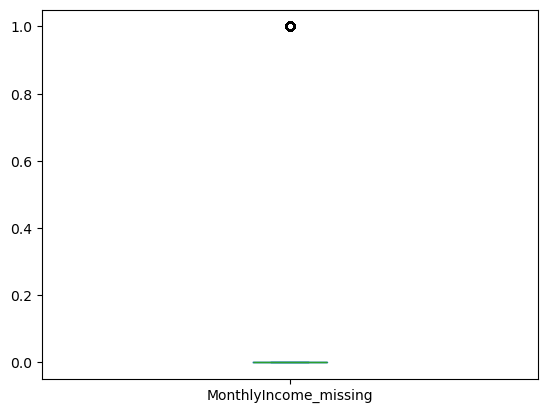

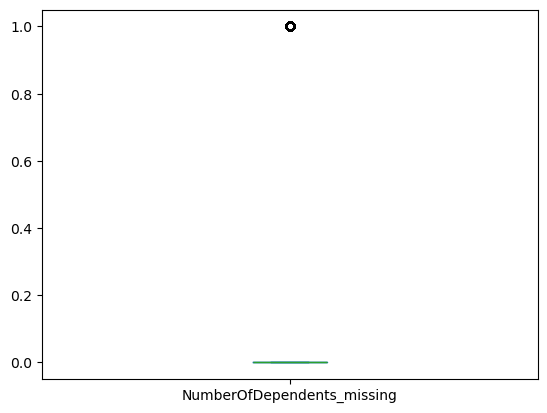

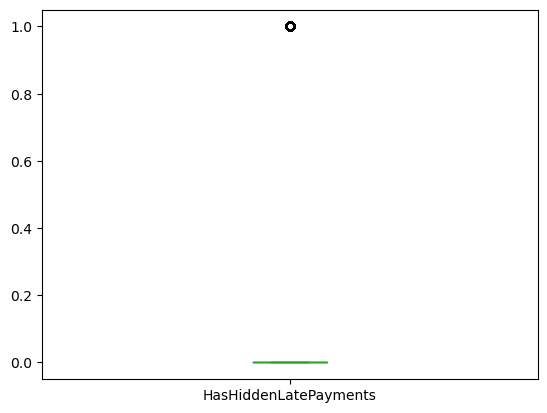

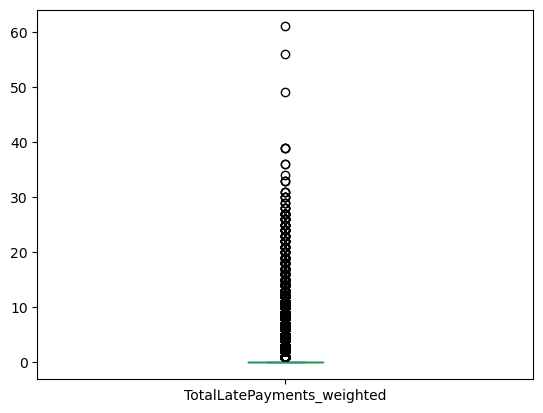

In [58]:
for col in df.columns:
    df[col].plot(kind='box')
    plt.show()

Для скошенных распределений лучше использовать Modefied Z-score с базовыми параметрами 0.6745  и порогом Mi > 3.5

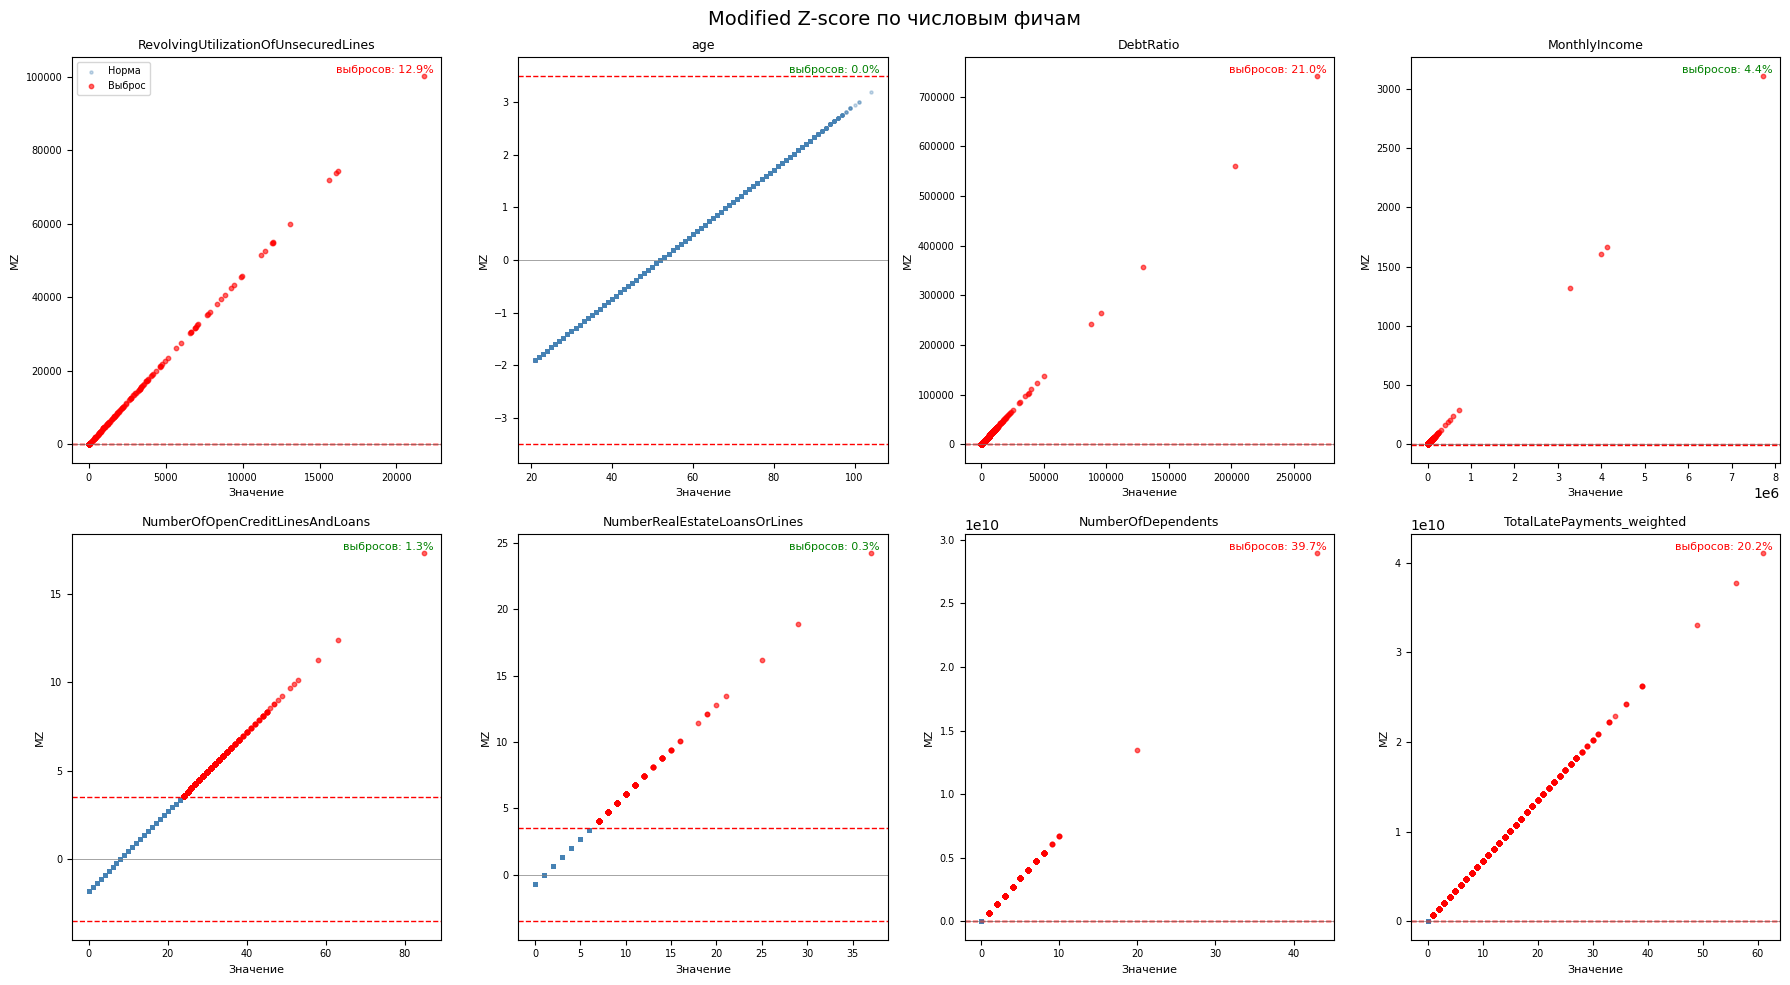

In [59]:
num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "TotalLatePayments_weighted"
]

THRESHOLD = 3.5

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Modified Z-score по числовым фичам", fontsize=14)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    series = df[col].dropna().values

    # Считаем Modified Z-score
    med = np.median(series)
    mad = np.median(np.abs(series - med))
    mz  = 0.6745 * (series - med) / (mad + 1e-9)

    is_outlier = np.abs(mz) > THRESHOLD
    pct = is_outlier.mean() * 100

    # Scatter: исходное значение vs MZ
    ax.scatter(series[~is_outlier], mz[~is_outlier],
               color="steelblue", s=5, alpha=0.3, label="Норма")
    ax.scatter(series[is_outlier], mz[is_outlier],
               color="red", s=10, alpha=0.6, label="Выброс")

    # Линии порога
    ax.axhline(+THRESHOLD, color="red", linestyle="--", linewidth=1)
    ax.axhline(-THRESHOLD, color="red", linestyle="--", linewidth=1)
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)

    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Значение", fontsize=8)
    ax.set_ylabel("MZ", fontsize=8)
    ax.tick_params(labelsize=7)

    # Статистика в углу
    ax.text(0.98, 0.98, f"выбросов: {pct:.1f}%",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="red" if pct > 5 else "green")

axes[0].legend(fontsize=7)

plt.tight_layout()
plt.show()

RevolvingUtilization \
  Основная прямая ниже пунктира (синие) \
  Резкий разрыв — красные точки далеко вверху \
  12.5% выбросов\
  → явные аномалии, значения до 50 000 при норме 0-1 

DebtRatio \
  Основная прямая почти горизонтальна у нуля \
  Красные точки улетают до 400 000+ \
  21.2% выбросов \
  → экстремальные выбросы, деление на 0 

NumberOfDependents \
  Почти ВСЕ точки красные (39.4%) \
  Прямая сразу уходит за пунктир \
  → MZ сломан: медиана=0, MAD=0 \
  → метод не применим 

In [60]:
df[df["RevolvingUtilizationOfUnsecuredLines"] > 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,HasHiddenLatePayments,TotalLatePayments_weighted
0,NaN,0.885519,43,0.0,0.177513,5700.0,4,0.0,0,0.0,0.0,0,0,0,0.0
1,NaN,0.463295,57,0.0,0.527237,9141.0,15,0.0,4,0.0,2.0,0,0,0,0.0
2,NaN,0.043275,59,0.0,0.687648,5083.0,12,0.0,1,0.0,2.0,0,0,0,0.0
3,NaN,0.280308,38,1.0,0.925961,3200.0,7,0.0,2,0.0,0.0,0,0,0,1.0
4,NaN,1.000000,27,0.0,0.019917,3865.0,4,0.0,0,0.0,1.0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101498,NaN,0.282653,24,0.0,0.068522,1400.0,5,0.0,0,0.0,0.0,0,0,0,0.0
101499,NaN,0.922156,36,3.0,0.934217,7615.0,8,0.0,2,0.0,4.0,0,0,0,3.0
101500,NaN,0.081596,70,0.0,836.000000,5400.0,3,0.0,0,0.0,0.0,1,1,0,0.0
101501,NaN,0.335457,56,0.0,3568.000000,5400.0,8,0.0,2,1.0,3.0,1,0,0,2.0


In [61]:
mask = df["RevolvingUtilizationOfUnsecuredLines"] > 5

print(f"Количество: {df.sum()}")
# print(f"Процент от датасета: {df.mean()*100}%")

print(df.loc[mask, "RevolvingUtilizationOfUnsecuredLines"].describe())

print(f"\nДефолт среди > 5:  {df.loc[mask,  'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт среди <= 5: {df.loc[~mask, 'SeriousDlqin2yrs'].mean():.4f}")


Количество: SeriousDlqin2yrs                        0.000000e+00
RevolvingUtilizationOfUnsecuredLines    5.389810e+05
age                                     5.319309e+06
NumberOfTime30-59DaysPastDueNotWorse    2.508900e+04
DebtRatio                               3.496525e+07
MonthlyIncome                           6.665561e+08
NumberOfOpenCreditLinesAndLoans         8.580570e+05
NumberOfTimes90DaysLate                 9.145000e+03
NumberRealEstateLoansOrLines            1.028300e+05
NumberOfTime60-89DaysPastDueNotWorse    6.468000e+03
NumberOfDependents                      7.604100e+04
MonthlyIncome_missing                   2.010300e+04
NumberOfDependents_missing              2.626000e+03
HasHiddenLatePayments                   2.140000e+02
TotalLatePayments_weighted              6.546000e+04
dtype: float64
count      161.000000
mean      3144.301717
std       3805.096884
min          5.062129
25%        607.000000
50%       1690.000000
75%       3850.000000
max      21821.000000
Na

In [62]:
df["RevolvingUtilizationOfUnsecuredLines"] = (
    df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1)
)

# Проверка
print(df["RevolvingUtilizationOfUnsecuredLines"].max())   # → 1.0
print(df["RevolvingUtilizationOfUnsecuredLines"].describe())

1.0
count    101503.000000
mean          0.320059
std           0.350568
min           0.000000
25%           0.030131
50%           0.152586
75%           0.564225
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


<Axes: >

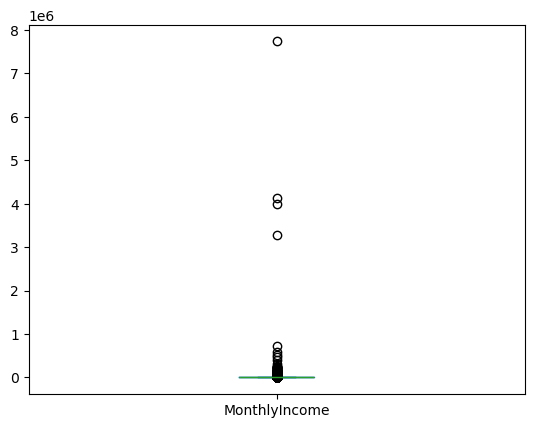

In [63]:
df["MonthlyIncome"].plot(kind='box')

<Axes: >

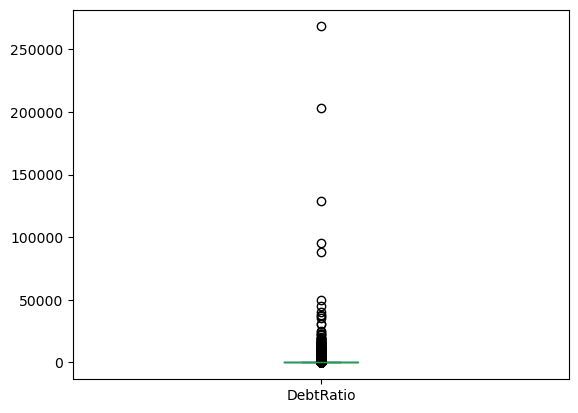

In [64]:
df["DebtRatio"].plot(kind='box')

Посмотрим какой доход у тех, кто имеет DebtRatio > 1000 (по умолчанию должен быть от 0 до 1)

In [65]:
mask = df["DebtRatio"] > 1000

print(f"\nMonthlyIncome у них:")
print(df.loc[mask, "MonthlyIncome"].value_counts().head())


MonthlyIncome у них:
MonthlyIncome
5400.0    10695
0.0         467
1.0         126
2.0           1
Name: count, dtype: int64


In [66]:
mask_0 = (df["DebtRatio"] > 1000) & (df["MonthlyIncome"] == 0)
mask_1 = (df["DebtRatio"] > 1000) & (df["MonthlyIncome"] == 1)

print("MonthlyIncome = 0")
print(f"Количество: {mask_0.sum()}")
print(f"Дефолт: {df.loc[mask_0, 'SeriousDlqin2yrs'].mean():.4f}")
print(df.loc[mask_0, ["DebtRatio", "MonthlyIncome", "age", "NumberOfDependents"]].describe())

print("\nMonthlyIncome = 1")
print(f"Количество: {mask_1.sum()}")
print(f"Дефолт: {df.loc[mask_1, 'SeriousDlqin2yrs'].mean():.4f}")
print(df.loc[mask_1, ["DebtRatio", "MonthlyIncome", "age", "NumberOfDependents"]].describe())


MonthlyIncome = 0
Количество: 467
Дефолт: nan
           DebtRatio  MonthlyIncome         age  NumberOfDependents
count     467.000000          467.0  467.000000          467.000000
mean     3933.171306            0.0   49.614561            1.064240
std     11388.747190            0.0   12.014710            1.503981
min      1004.000000            0.0   23.000000            0.000000
25%      1649.500000            0.0   41.000000            0.000000
50%      2312.000000            0.0   48.000000            0.000000
75%      3455.500000            0.0   58.000000            2.000000
max    202990.000000            0.0   95.000000           20.000000

MonthlyIncome = 1
Количество: 126
Дефолт: nan
         DebtRatio  MonthlyIncome         age  NumberOfDependents
count   126.000000          126.0  126.000000          126.000000
mean   1841.432540            1.0   48.936508            1.214286
std    1056.482101            0.0    9.321584            1.287523
min    1004.000000            1

In [67]:
print("Средний возраст при income=0:", df.loc[mask_0, "age"].mean())
print("Средний возраст при income=1:", df.loc[mask_1, "age"].mean())
print("Средний возраст по датасету: ", df["age"].mean())

# Смотрим иждивенцев — если есть → скорее семья с одним кормильцем
print("\nИждивенцы при income=0:", df.loc[mask_0, "NumberOfDependents"].mean())
print("Иждивенцы при income=1:", df.loc[mask_1, "NumberOfDependents"].mean())


Средний возраст при income=0: 49.61456102783726
Средний возраст при income=1: 48.93650793650794
Средний возраст по датасету:  52.405436292523376

Иждивенцы при income=0: 1.0642398286937902
Иждивенцы при income=1: 1.2142857142857142


Обе группы имеют дефолт НИЖЕ среднего:

  income = 0  →  дефолт 4.85%  vs  среднее 6.7%
  income = 1  →  дефолт 3.69%  vs  среднее 6.7%

Это значит:
  → это НЕ проблемные клиенты
  → это скорее состоятельные люди без официального дохода
  → или технические артефакты базы данных
  → DebtRatio огромный потому что деление на 0 или на 1

In [68]:
# income = 1 — заменяем на NaN (технический артефакт)
df.loc[df["MonthlyIncome"] == 1, "MonthlyIncome"] = np.nan
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(
    df["MonthlyIncome"].median()
)

# DebtRatio для обоих — clip по p99
# DebtRatio огромный из-за деления на 0/1, не несёт реального смысла
p99 = df["DebtRatio"].quantile(0.99)
print(f"DebtRatio p99: {p99:.2f}")
df["DebtRatio"] = df["DebtRatio"].clip(upper=p99)

DebtRatio p99: 4963.00


<Axes: >

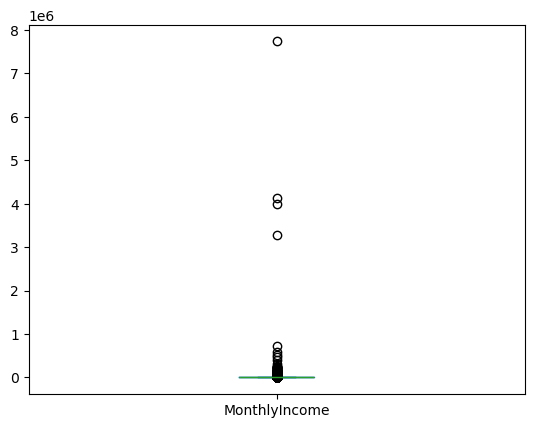

In [69]:
df["MonthlyIncome"].plot(kind='box')

<Axes: >

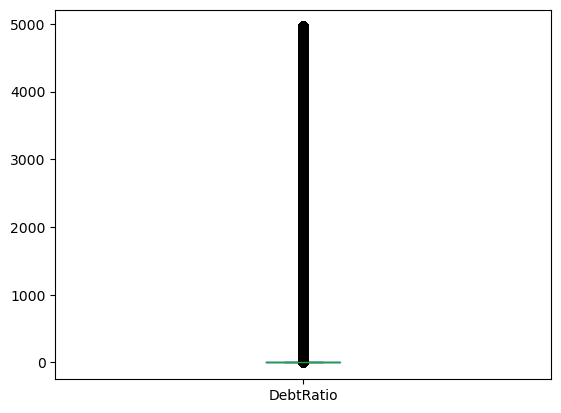

In [70]:
df["DebtRatio"].plot(kind='box')

In [71]:
mask_rich = df["MonthlyIncome"] > df["MonthlyIncome"].quantile(0.99)
print(df.loc[mask_rich,  "SeriousDlqin2yrs"].mean())
print(df.loc[~mask_rich, "SeriousDlqin2yrs"].mean())

nan
nan


Проверим дубликаты: 

In [72]:
n_full = df.duplicated().sum()
print(f"Полных дубликатов: {n_full}")

# orig_cols = [
#     "RevolvingUtilizationOfUnsecuredLines",
#     "age",
#     "DebtRatio",
#     "MonthlyIncome",
#     "NumberOfOpenCreditLinesAndLoans",
#     "NumberRealEstateLoansOrLines",
#     "NumberOfDependents"
# ]

orig_cols = df.columns

n_orig = df.duplicated(subset=orig_cols).sum()
print(f"Дубликатов по оригинальным фичам: {n_orig}")

# Смотрим дефолт у дубликатов
dup_mask = df.duplicated(subset=orig_cols, keep=False)
print(f"\nДефолт у дубликатов:      {df.loc[dup_mask,  'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт у уникальных:      {df.loc[~dup_mask, 'SeriousDlqin2yrs'].mean():.4f}")


Полных дубликатов: 330
Дубликатов по оригинальным фичам: 330

Дефолт у дубликатов:      nan
Дефолт у уникальных:      nan


In [73]:
# df = df.drop_duplicates(keep="first")

In [74]:
print(f"Размер после удаления: {df.shape}")


Размер после удаления: (101503, 15)


WoE & IV analysis

In [75]:
def calc_woe_iv(df, feature, target, bins=10):
    # Разбиваем на бакеты
    df = df[[feature, target]].copy().dropna()
    df["bucket"] = pd.qcut(df[feature], q=bins, duplicates="drop")

    grouped = df.groupby("bucket")[target].agg(["sum", "count"])
    grouped.columns = ["defaults", "total"]
    grouped["non_defaults"] = grouped["total"] - grouped["defaults"]

    total_def     = grouped["defaults"].sum()
    total_non_def = grouped["non_defaults"].sum()


    grouped["pct_def"]     = grouped["defaults"]     / total_def
    grouped["pct_non_def"] = grouped["non_defaults"] / total_non_def

    # WoE и IV
    grouped["WoE"] = np.log(grouped["pct_non_def"] / grouped["pct_def"])
    grouped["IV"]  = (grouped["pct_non_def"] - grouped["pct_def"]) * grouped["WoE"]

    iv_total = grouped["IV"].sum()
    return grouped, iv_total

In [76]:
num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "TotalLatePayments_weighted"
]

iv_results = {}
for col in num_cols:
    _, iv = calc_woe_iv(df, col, "SeriousDlqin2yrs")
    iv_results[col] = iv

# Сортируем по IV
iv_df = pd.Series(iv_results).sort_values(ascending=False)
print(iv_df)

RevolvingUtilizationOfUnsecuredLines    0.0
age                                     0.0
DebtRatio                               0.0
MonthlyIncome                           0.0
NumberOfOpenCreditLinesAndLoans         0.0
NumberRealEstateLoansOrLines            0.0
NumberOfDependents                      0.0
TotalLatePayments_weighted              0.0
dtype: float64


C:\Users\Danch\AppData\Local\Temp\ipykernel_22512\2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])
C:\Users\Danch\AppData\Local\Temp\ipykernel_22512\2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])
C:\Users\Danch\AppData\Local\Temp\ipykernel_22512\2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future

C:\Users\Danch\AppData\Local\Temp\ipykernel_22512\2270524923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bucket")[target].agg(["sum", "count"])


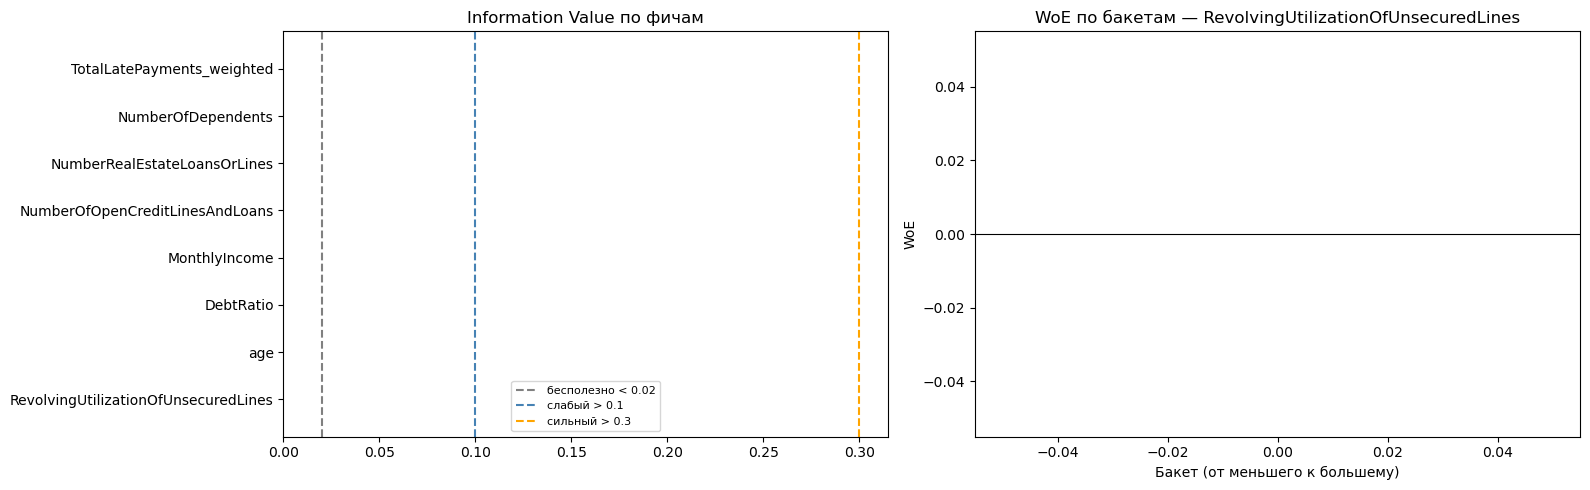

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1 — IV по фичам
colors = []
for v in iv_df.values:
    if v < 0.02:
        colors.append("gray")
    elif v < 0.1:
        colors.append("steelblue")
    elif v < 0.3:
        colors.append("orange")
    else:
        colors.append("red")

axes[0].barh(iv_df.index, iv_df.values, color=colors)
axes[0].axvline(0.02, color="gray",   linestyle="--", label="бесполезно < 0.02")
axes[0].axvline(0.1,  color="steelblue", linestyle="--", label="слабый > 0.1")
axes[0].axvline(0.3,  color="orange", linestyle="--", label="сильный > 0.3")
axes[0].set_title("Information Value по фичам")
axes[0].legend(fontsize=8)

best_col = iv_df.index[0]
woe_df, _ = calc_woe_iv(df, best_col, "SeriousDlqin2yrs")

axes[1].bar(range(len(woe_df)), woe_df["WoE"],
            color=["red" if w < 0 else "steelblue" for w in woe_df["WoE"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"WoE по бакетам — {best_col}")
axes[1].set_xlabel("Бакет (от меньшего к большему)")
axes[1].set_ylabel("WoE")

plt.tight_layout()
plt.show()

1. TotalLatePayments и Revolving — два главных предиктора
   Модель будет опираться именно на них

2. NumberRealEstateLoansOrLines — можно удалить
   IV < 0.02, почти не несёт информации

3. NumberOfDependents — на грани
   IV ≈ 0.02, оставить только флаг который мы создали

4. IV > 0.5 у двух фичей — проверь нет ли утечки данных!
   TotalLatePayments = мы сами создали из просрочек
   Revolving = оригинальная фича

   TotalLatePayments логично имеет высокий IV —
   просрочки напрямую связаны с дефолтом, это нормально

In [78]:
# Проверяем перед удалением
print(df["NumberRealEstateLoansOrLines"].value_counts().head())
print(f"Дефолт = 0 loans: {df.loc[df['NumberRealEstateLoansOrLines']==0, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"Дефолт > 0 loans: {df.loc[df['NumberRealEstateLoansOrLines']>0,  'SeriousDlqin2yrs'].mean():.4f}")

# Если разницы нет — удаляем
# df.drop(columns=["NumberRealEstateLoansOrLines"], inplace=True)

NumberRealEstateLoansOrLines
0    38066
1    35670
2    20955
3     4423
4     1414
Name: count, dtype: int64
Дефолт = 0 loans: nan
Дефолт > 0 loans: nan


In [79]:
print(df.groupby("NumberRealEstateLoansOrLines")["SeriousDlqin2yrs"].mean())


NumberRealEstateLoansOrLines
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
18   NaN
19   NaN
20   NaN
21   NaN
25   NaN
29   NaN
37   NaN
Name: SeriousDlqin2yrs, dtype: float64


Сохраним трейн в разные датасеты - 1 для бейзлайн моделей, второй для трансформеров

In [80]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing', 'HasHiddenLatePayments',
       'TotalLatePayments_weighted'],
      dtype='object')

In [81]:
df.to_csv("test_give_me_credit_baseline.csv")

In [82]:
fe_cols = [
    "TotalLatePayments_weighted",
    "HasHiddenLatePayments",
    "MonthlyIncome_missing",
    "NumberOfDependents_missing",
    "Revolving_over_limit"
]

df_transformer = df.drop(
    columns=[c for c in fe_cols if c in df.columns]
)

# Проверка
print(f"Baseline колонки:     {df.columns.tolist()}")
print(f"Transformer колонки:  {df_transformer.columns.tolist()}")

Baseline колонки:     ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'NumberOfDependents_missing', 'HasHiddenLatePayments', 'TotalLatePayments_weighted']
Transformer колонки:  ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [83]:
df_transformer.to_csv("test_give_me_credit_transformer.csv")

In [84]:
len(df)

101503